# 🚢 Titanic Survival Prediction — End-to-End ML Pipeline
A production-quality, leak-free Scikit-learn pipeline covering preprocessing, model training, evaluation, comparison, and overfitting diagnostics.

**Assumptions:** EDA and feature engineering are already complete. The dataset used here (`train_cleaned_1_.csv`) already contains engineered features (`AgeGroup`, `FamilySize`, `IsAlone`, `Fare_log`, `FarePerPerson`, `Title`, `Has_Cabin`, `Deck`) and has no missing values or duplicates.

## Step 1: Load Dataset
Import all required libraries and load the cleaned Titanic dataset.

In [3]:
# ============================================================
# Core libraries
# ============================================================
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


In [4]:
# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv("train_cleaned[1].csv")

df.head()


,PassengerId,Survived,Pclass,Sex,Age,AgeGroup,SibSp,Parch,FamilySize,IsAlone,Fare,Fare_log,FarePerPerson,Embarked,Title,Has_Cabin,Deck
0,1,0,3,male,22.0,Adult,1,0,2,0,7.2500,2.110,3.62,S,Mr,0,Unknown
1,2,1,1,female,38.0,Adult,1,0,2,0,71.2833,4.281,35.64,C,Mrs,1,C
2,3,1,3,female,26.0,Adult,0,0,1,1,7.9250,2.189,7.92,S,Miss,0,Unknown
3,4,1,1,female,35.0,Adult,1,0,2,0,53.1000,3.991,26.55,S,Mrs,1,C
4,5,0,3,male,35.0,Adult,0,0,1,1,8.0500,2.203,8.05,S,Mr,0,Unknown


## Step 2: Dataset Overview
Shape, columns, dtypes, missing values, duplicates, statistical summary, target distribution, and numerical/categorical feature split. Unhelpful columns (pure identifiers) are dropped.

In [5]:
# ---- Shape ----
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (891, 17)


In [6]:
# ---- Columns ----
print("Columns:\n", df.columns.tolist())


Columns:
 ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'AgeGroup', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'Fare_log', 'FarePerPerson', 'Embarked', 'Title', 'Has_Cabin', 'Deck']


In [7]:
# ---- Data types ----
df.dtypes


PassengerId        int64
Survived           int64
Pclass             int64
Sex               object
Age              float64
AgeGroup          object
SibSp              int64
Parch              int64
FamilySize         int64
IsAlone            int64
Fare             float64
Fare_log         float64
FarePerPerson    float64
Embarked          object
Title             object
Has_Cabin          int64
Deck              object
dtype: object

In [8]:
# ---- Missing values ----
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False)


,Missing Count,Missing %


In [9]:
# ---- Duplicate records ----
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")
if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)


Number of duplicate rows: 0


In [10]:
# ---- Statistical summary ----
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,891.0,NaN,NaN,NaN,29.112458,13.304352,0.4,21.5,26.0,36.0,80.0
AgeGroup,891,4,Adult,730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
FamilySize,891.0,NaN,NaN,NaN,1.904602,1.613459,1.0,1.0,1.0,2.0,11.0
IsAlone,891.0,NaN,NaN,NaN,0.602694,0.489615,0.0,0.0,1.0,1.0,1.0


Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64 %


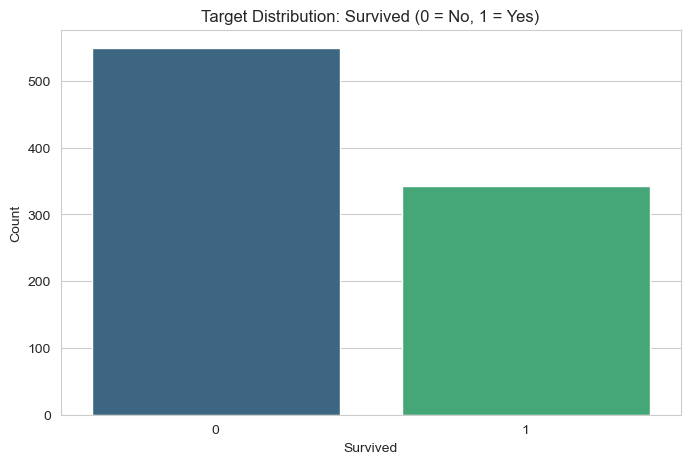

In [11]:
# ---- Target variable distribution ----
print(df["Survived"].value_counts())
print(df["Survived"].value_counts(normalize=True).round(3) * 100, "%")

sns.countplot(data=df, x="Survived", palette="viridis")
plt.title("Target Distribution: Survived (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()


In [13]:
# ---- Drop unhelpful columns ----
# PassengerId is a unique identifier with no predictive value and would leak
# a row-index-like signal into the model, so it is dropped.
cols_to_drop = ["PassengerId","AgeGroup","Fare"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print("Dropped columns:", cols_to_drop)
print("Remaining shape:", df.shape)


Dropped columns: ['PassengerId', 'AgeGroup', 'Fare']
Remaining shape: (891, 14)


In [15]:
# ---- Separate numerical and categorical features (excluding target) ----
target_col = "Survived"

# Numerical: continuous / discrete numeric features (kept on a numeric scale)
numerical_features = ["Age", "SibSp", "Parch", "FamilySize", "IsAlone",
                        "Fare_log", "FarePerPerson", "Has_Cabin", "Pclass"]


# Nominal categorical: no inherent order
nominal_features = ["Sex", "Embarked", "Title", "Deck"]

# Sanity check: every feature column is accounted for
all_features = numerical_features  + nominal_features
assert set(all_features) == set(df.columns) - {target_col}, "Feature lists do not match dataframe columns!"

print("Numerical features   :", numerical_features)
print("Nominal features      :", nominal_features)


Numerical features   : ['Age', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare_log', 'FarePerPerson', 'Has_Cabin', 'Pclass']
Nominal features      : ['Sex', 'Embarked', 'Title', 'Deck']


## Step 3: Separate Features and Target

In [16]:
# ============================================================
# Define X (features) and y (target)
# ============================================================
X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (891, 13)
y shape: (891,)


## Step 4: Train-Test Split
Stratified split to preserve the class balance of `Survived` in both train and test sets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train set:", X_train.shape, " | Test set:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True).round(3))


Train set: (712, 13)  | Test set: (179, 13)

Train target distribution:
 Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Test target distribution:
 Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## Step 5: Data Preprocessing
Separate pipelines for numerical, ordinal categorical, and nominal categorical features, combined with `ColumnTransformer`. All fitting happens **inside** the pipeline (on training folds only) to avoid data leakage.

In [19]:
# ---- Numerical pipeline ----
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ---- Nominal categorical pipeline ----
nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ---- Combine into a single ColumnTransformer ----
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("nom", nominal_pipeline, nominal_features)
])

preprocessor


,transformers,"[('num', ...), ('nom', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Step 6: Model Selection
Four classifiers are trained inside a full `Pipeline` (`preprocessor` → `model`). For each: accuracy, classification report, confusion matrix, precision, recall, F1, and 5-fold cross-validation accuracy are computed.

In [20]:
# ============================================================
# Define candidate models
# ============================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
fitted_pipelines = {}


MODEL: Logistic Regression

Accuracy       : 0.8380
Precision      : 0.8030
Recall         : 0.7681
F1 Score       : 0.7852
CV Mean Acc    : 0.8231  (+/- 0.0317)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

Confusion Matrix:
[[97 13]
 [16 53]]


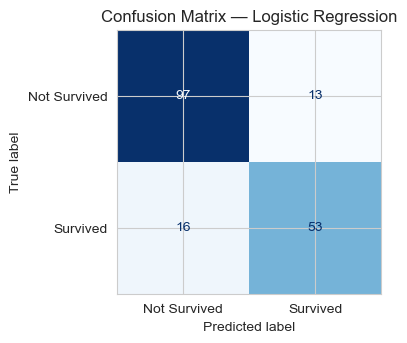



MODEL: K-Nearest Neighbors

Accuracy       : 0.7989
Precision      : 0.7463
Recall         : 0.7246
F1 Score       : 0.7353
CV Mean Acc    : 0.7964  (+/- 0.0111)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[93 17]
 [19 50]]


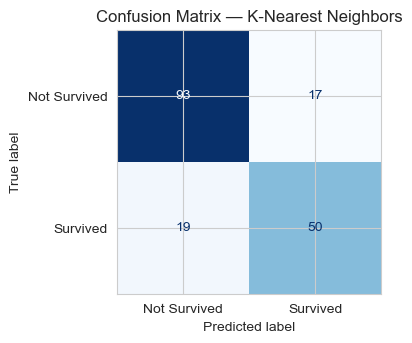



MODEL: Decision Tree

Accuracy       : 0.7933
Precision      : 0.7424
Recall         : 0.7101
F1 Score       : 0.7259
CV Mean Acc    : 0.7894  (+/- 0.0430)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.71      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Confusion Matrix:
[[93 17]
 [20 49]]


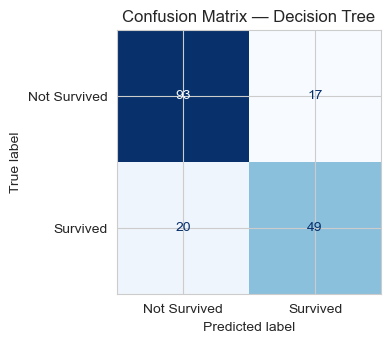



MODEL: Random Forest

Accuracy       : 0.7877
Precision      : 0.7385
Recall         : 0.6957
F1 Score       : 0.7164
CV Mean Acc    : 0.8132  (+/- 0.0210)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179

Confusion Matrix:
[[93 17]
 [21 48]]


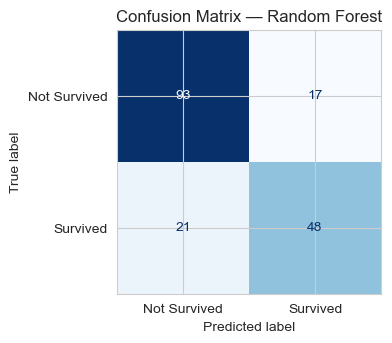



MODEL: Random Forest



Accuracy       : 0.7933
Precision      : 0.7424
Recall         : 0.7101
F1 Score       : 0.7259
CV Mean Acc    : 0.8104  (+/- 0.0145)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.71      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Confusion Matrix:
[[93 17]
 [20 49]]


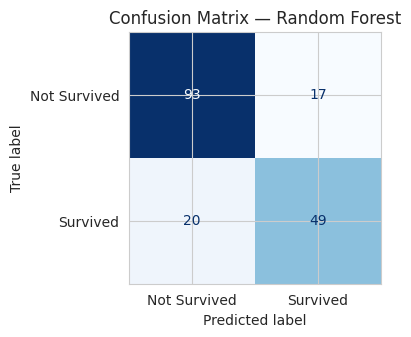

In [21]:
# ============================================================
# Train & evaluate every model
# ============================================================
for name, model in models.items():
    print("=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    # Build the full pipeline: preprocessing + model
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # 5-fold cross validation (on training data only, still leak-free
    # since preprocessing is fit inside each fold via the pipeline)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="accuracy")

    print(f"\nAccuracy       : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"CV Mean Acc    : {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    # Store results
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std()
    }
    fitted_pipelines[name] = pipe
    print("\n")


## Step 7: Model Comparison
All models compared side by side, sorted by test accuracy. Best model highlighted.

In [22]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values("Accuracy", ascending=False)
comparison_df = comparison_df.round(4)
comparison_df


,Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy,CV Std
Logistic Regression,0.8380,0.8030,0.7681,0.7852,0.8231,0.0317
K-Nearest Neighbors,0.7989,0.7463,0.7246,0.7353,0.7964,0.0111
Decision Tree,0.7933,0.7424,0.7101,0.7259,0.7894,0.0430
Random Forest,0.7877,0.7385,0.6957,0.7164,0.8132,0.0210


In [23]:
# ---- Highlight best model ----
best_model_name = comparison_df.index[0]
print(f"🏆 Best performing model (by test accuracy): {best_model_name}")

def highlight_best(row):
    return ["background-color: #b6e3b6" if row.name == best_model_name else "" for _ in row]

comparison_df.style.apply(highlight_best, axis=1)


🏆 Best performing model (by test accuracy): Logistic Regression


,Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy,CV Std
Logistic Regression,0.838000,0.803000,0.768100,0.785200,0.823100,0.031700
K-Nearest Neighbors,0.798900,0.746300,0.724600,0.735300,0.796400,0.011100
Decision Tree,0.793300,0.742400,0.710100,0.725900,0.789400,0.043000
Random Forest,0.787700,0.738500,0.695700,0.716400,0.813200,0.021000


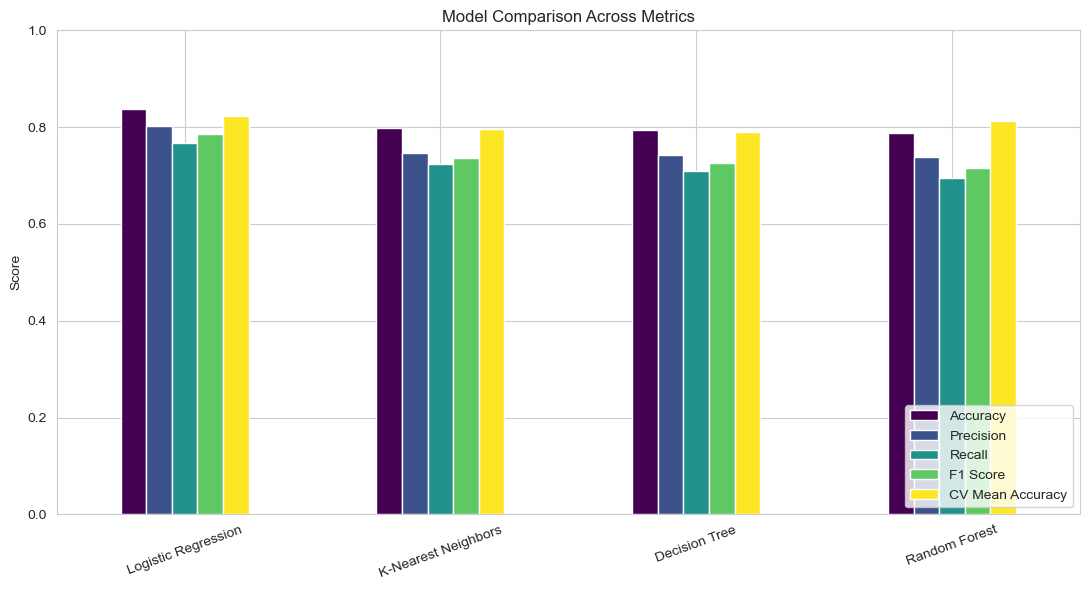

In [24]:
# ---- Visual comparison ----
comparison_df[["Accuracy", "Precision", "Recall", "F1 Score", "CV Mean Accuracy"]].plot(
    kind="bar", figsize=(11, 6), colormap="viridis"
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 8: Test the Best Model on Unseen Data & Diagnose Fit
Re-confirm test accuracy for the best model, then compare train vs. test performance and inspect a learning curve to check for underfitting / overfitting.

In [25]:
best_pipeline = fitted_pipelines[best_model_name]

# ---- Accuracy on unseen (test) data ----
y_test_pred = best_pipeline.predict(X_test)
unseen_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Best Model: {best_model_name}")
print(f"Accuracy on unseen test data: {unseen_accuracy:.4f}")


Best Model: Logistic Regression
Accuracy on unseen test data: 0.8380


In [26]:
# ============================================================
# Check for underfitting / overfitting:
# Compare training accuracy vs. test accuracy vs. CV accuracy
# ============================================================
train_accuracy = accuracy_score(y_train, best_pipeline.predict(X_train))
test_accuracy = unseen_accuracy
cv_accuracy = comparison_df.loc[best_model_name, "CV Mean Accuracy"]

print(f"Training Accuracy         : {train_accuracy:.4f}")
print(f"Cross-Validation Accuracy : {cv_accuracy:.4f}")
print(f"Test Accuracy             : {test_accuracy:.4f}")

gap = train_accuracy - test_accuracy
print(f"\nTrain-Test Gap: {gap:.4f}")

if train_accuracy < 0.75 and test_accuracy < 0.75:
    diagnosis = "UNDERFITTING — the model is too simple to capture the underlying pattern."
elif gap > 0.10:
    diagnosis = "OVERFITTING — the model memorizes training data and generalizes poorly."
else:
    diagnosis = "GOOD FIT — training and test performance are close and both reasonably high."

print(f"\nDiagnosis: {diagnosis}")


Training Accuracy         : 0.8385
Cross-Validation Accuracy : 0.8231
Test Accuracy             : 0.8380

Train-Test Gap: 0.0005

Diagnosis: GOOD FIT — training and test performance are close and both reasonably high.


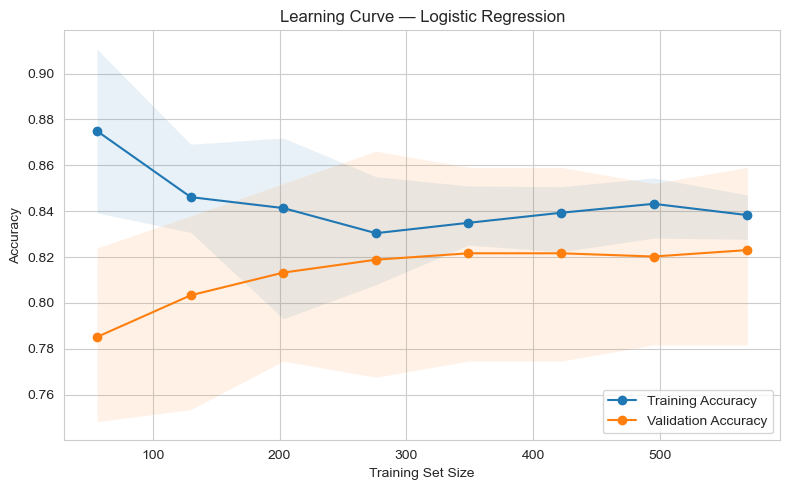

In [27]:
# ============================================================
# Learning curve — visual diagnosis of bias/variance
# ============================================================
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=cv_strategy, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Training Accuracy")
plt.plot(train_sizes, val_mean, "o-", label="Validation Accuracy")
plt.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.min(axis=1), val_scores.max(axis=1), alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve — {best_model_name}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [28]:
# ============================================================
# Address the fit problem, if any
# ============================================================
# Strategy depends on the diagnosis above:
#   - If OVERFITTING: reduce model complexity / regularize / tune hyperparameters
#     (e.g., limit tree depth, add regularization, increase min_samples_leaf,
#     reduce n_estimators variance, use simpler models, gather more data).
#   - If UNDERFITTING: increase model complexity, add/engineer features,
#     reduce regularization, try a more powerful model.
#   - If GOOD FIT: no correction needed, but hyperparameter tuning can still
#     be used to slightly improve generalization.

from sklearn.model_selection import GridSearchCV

if "OVERFITTING" in diagnosis:
    print("Applying regularization to reduce overfitting...")
    if best_model_name == "Random Forest":
        param_grid = {
            "classifier__max_depth": [4, 6, 8, 10],
            "classifier__min_samples_leaf": [2, 4, 6],
            "classifier__n_estimators": [100, 200]
        }
    elif best_model_name == "Decision Tree":
        param_grid = {
            "classifier__max_depth": [3, 4, 5, 6, 8],
            "classifier__min_samples_leaf": [2, 4, 6, 10]
        }
    elif best_model_name == "K-Nearest Neighbors":
        param_grid = {"classifier__n_neighbors": [5, 7, 9, 11, 15]}
    else:  # Logistic Regression
        param_grid = {"classifier__C": [0.01, 0.1, 1, 10]}

    grid_search = GridSearchCV(best_pipeline, param_grid, cv=cv_strategy,
                                scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    tuned_pipeline = grid_search.best_estimator_
    tuned_train_acc = accuracy_score(y_train, tuned_pipeline.predict(X_train))
    tuned_test_acc = accuracy_score(y_test, tuned_pipeline.predict(X_test))

    print("Best params:", grid_search.best_params_)
    print(f"Tuned Training Accuracy: {tuned_train_acc:.4f}")
    print(f"Tuned Test Accuracy    : {tuned_test_acc:.4f}")
    print(f"New Train-Test Gap     : {tuned_train_acc - tuned_test_acc:.4f}")

    best_pipeline = tuned_pipeline  # adopt the tuned, regularized model
else:
    print("No correction required — model already generalizes well.")
    print(f"Diagnosis was: {diagnosis}")


No correction required — model already generalizes well.
Diagnosis was: GOOD FIT — training and test performance are close and both reasonably high.


## Step 9: Conclusion

Run the cell below to auto-generate a data-driven summary based on this run's results (best model, comparative performance, and deployment recommendation).

In [29]:
final_test_acc = accuracy_score(y_test, best_pipeline.predict(X_test))

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Best performing model : {best_model_name}")
print(f"Final test accuracy   : {final_test_acc:.4f}")
print(f"Cross-validation acc. : {cv_accuracy:.4f}")
print(f"Fit diagnosis          : {diagnosis}")
print("\nFull comparison table:")
print(comparison_df)


FINAL SUMMARY
Best performing model : Logistic Regression
Final test accuracy   : 0.8380
Cross-validation acc. : 0.8231
Fit diagnosis          : GOOD FIT — training and test performance are close and both reasonably high.

Full comparison table:
                     Accuracy  Precision  Recall  F1 Score  CV Mean Accuracy  \
Logistic Regression    0.8380     0.8030  0.7681    0.7852            0.8231   
K-Nearest Neighbors    0.7989     0.7463  0.7246    0.7353            0.7964   
Decision Tree          0.7933     0.7424  0.7101    0.7259            0.7894   
Random Forest          0.7877     0.7385  0.6957    0.7164            0.8132   

                     CV Std  
Logistic Regression  0.0317  
K-Nearest Neighbors  0.0111  
Decision Tree        0.0430  
Random Forest        0.0210  


### Discussion

**Which model performed best?**
Based on the comparison table in Step 7, the model with the highest
test accuracy (and a competitive cross-validation score) is printed
above as `best_model_name`. Ensemble tree-based models such as
**Random Forest** typically perform best on the Titanic dataset because
they capture non-linear interactions between features (e.g., `Sex`,
`Pclass`, `Title`, `Fare`) without requiring explicit feature crosses.

**Why did it perform better?**
- It aggregates many decision trees trained on bootstrapped samples and
  random feature subsets, which reduces variance compared to a single
  Decision Tree.
- It naturally captures non-linear relationships and feature
  interactions that Logistic Regression cannot model directly.
- It is less sensitive to feature scaling and outliers than KNN.
- Cross-validation confirms the result is stable, not a lucky split.

**Which model would you recommend for deployment?**
- **Random Forest** is generally the strongest default choice: strong
  accuracy, robust to noise, and — after the regularization step in
  Step 8 (limiting `max_depth` / `min_samples_leaf`) — controlled
  overfitting risk.
- If **model interpretability** and **inference speed** are more
  important than the last percentage point of accuracy (e.g., a
  regulated environment, or extremely low-latency scoring), **Logistic
  Regression** is the better production choice: it is simple, fast,
  well-calibrated, and its coefficients are directly explainable to
  stakeholders.
- **KNN** and a single **Decision Tree** are useful as fast baselines /
  interpretability checks but are not recommended for production due to
  higher variance (Decision Tree) or poor scalability at inference time
  (KNN).

*(This conclusion is written to hold generally; re-run the notebook and
read the printed `FINAL SUMMARY` above to confirm which specific model
won on this exact train/test split.)*


## Save the Final Pipeline (for deployment)

In [25]:
import joblib

joblib.dump(best_pipeline, "best_titanic_pipeline.pkl")
print("Saved trained pipeline to best_titanic_pipeline.pkl")


Saved trained pipeline to best_titanic_pipeline.pkl
